# GalaxEye Change Detection Project

This project focuses on binary change detection using EO/SAR satellite imagery. The objective is to identify damaged and non-damaged regions from pre-event and post-event satellite images using deep learning segmentation models.

# Importing Required Libraries

In this section, we import all the necessary Python libraries required for data loading, preprocessing, visualization, deep learning model training, and evaluation.

In [ ]:
!pip install segmentation-models-pytorch

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import segmentation_models_pytorch as smp

# Mounting Google Drive

Google Drive is mounted to access the EO/SAR dataset and save trained models, outputs, and notebooks persistently.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Defining Dataset Paths

In this section, we define the paths for pre-event images, post-event images, and target masks from the EO/SAR dataset stored in Google Drive.

In [ ]:
train_pre_path = "/content/drive/MyDrive/galaxeye_dataset/train/pre-event"
train_post_path = "/content/drive/MyDrive/galaxeye_dataset/train/post-event"
train_target_path = "/content/drive/MyDrive/galaxeye_dataset/train/target"

print("Pre-event images:", len(os.listdir(train_pre_path)))
print("Post-event images:", len(os.listdir(train_post_path)))
print("Target masks:", len(os.listdir(train_target_path)))

Pre-event images: 2781
Post-event images: 2781
Target masks: 2781


# Visualizing Sample Images

Before training the deep learning model, we visualize a few samples from the dataset to understand the structure of pre-event images, post-event images, and target masks.

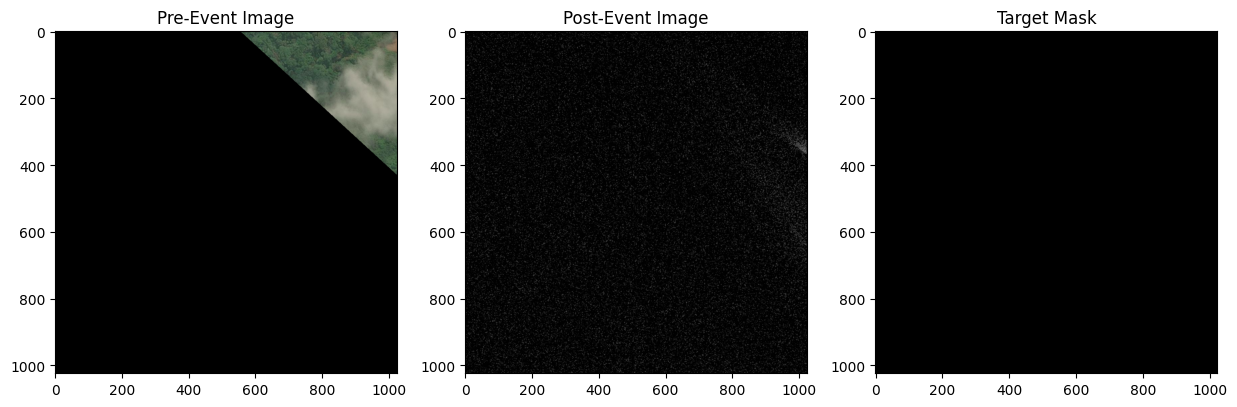

In [ ]:
sample_pre = os.path.join(train_pre_path, os.listdir(train_pre_path)[0])
sample_post = os.path.join(train_post_path, os.listdir(train_post_path)[0])
sample_target = os.path.join(train_target_path, os.listdir(train_target_path)[0])

pre_img = cv2.imread(sample_pre)
pre_img = cv2.cvtColor(pre_img, cv2.COLOR_BGR2RGB)

post_img = cv2.imread(sample_post)
post_img = cv2.cvtColor(post_img, cv2.COLOR_BGR2RGB)

target_img = cv2.imread(sample_target, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(pre_img)
plt.title("Pre-Event Image")

plt.subplot(1,3,2)
plt.imshow(post_img)
plt.title("Post-Event Image")

plt.subplot(1,3,3)
plt.imshow(target_img, cmap='gray')
plt.title("Target Mask")

plt.show()

# Creating Custom Dataset Class

A custom PyTorch Dataset class is created to load pre-event images, post-event images, and corresponding target masks. The images are resized and converted into tensors for model training.

In [ ]:
class ChangeDetectionDataset(Dataset):

    def __init__(self, pre_path, post_path, target_path):

        self.pre_images = sorted(os.listdir(pre_path))
        self.post_images = sorted(os.listdir(post_path))
        self.target_images = sorted(os.listdir(target_path))

        self.pre_path = pre_path
        self.post_path = post_path
        self.target_path = target_path

        self.transform = transforms.Compose([
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.pre_images)

    def __getitem__(self, idx):

        pre_img_path = os.path.join(self.pre_path, self.pre_images[idx])
        post_img_path = os.path.join(self.post_path, self.post_images[idx])
        target_img_path = os.path.join(self.target_path, self.target_images[idx])

        pre_img = cv2.imread(pre_img_path)
        pre_img = cv2.cvtColor(pre_img, cv2.COLOR_BGR2RGB)

        post_img = cv2.imread(post_img_path)
        post_img = cv2.cvtColor(post_img, cv2.COLOR_BGR2RGB)

        target_img = cv2.imread(target_img_path, cv2.IMREAD_GRAYSCALE)

        pre_img = cv2.resize(pre_img, (256, 256))
        post_img = cv2.resize(post_img, (256, 256))
        target_img = cv2.resize(target_img, (256, 256))

        target_img[target_img > 0] = 1

        pre_img = self.transform(pre_img)
        post_img = self.transform(post_img)

        target_img = torch.tensor(target_img, dtype=torch.float32)
        target_img = target_img.unsqueeze(0)

        input_img = torch.cat([pre_img, post_img], dim=0)

        return input_img, target_img

# Creating Dataset and DataLoader

The custom dataset is loaded using PyTorch DataLoader to efficiently create mini-batches for training the segmentation model.

In [ ]:
train_dataset = ChangeDetectionDataset(
    train_pre_path,
    train_post_path,
    train_target_path
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

print("Total Training Samples:", len(train_dataset))

Total Training Samples: 2781


# Building the Segmentation Model

A U-Net based segmentation architecture is used for binary change detection. The model takes concatenated pre-event and post-event images as input and predicts change masks.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=6,
    classes=1
)

model = model.to(device)

print("Using Device:", device)

Using Device: cpu


# Defining Loss Function and Optimizer

Binary Cross Entropy Loss is used for binary segmentation, and the Adam optimizer is used to update model parameters during training.

In [ ]:
criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

# Training the Model

The model is trained using mini-batch gradient descent. During each epoch, the model learns to predict binary change masks from pre-event and post-event satellite images.

In [23]:
num_epochs = 1

model.train()

for epoch in range(num_epochs):

    total_loss = 0

    for images, masks in tqdm(train_loader):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch Loss: {total_loss / len(train_loader)}")

100%|██████████| 696/696 [59:05<00:00,  5.09s/it]

Epoch Loss: 0.3043350363685482


In [24]:
torch.save(model.state_dict(), "/content/drive/MyDrive/GalaxEye_Project/model.pth")